In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: Model Selection & Pipelines
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

# Transformers
from feature_engine.transformation import YeoJohnsonTransformer

# Custom functions 
from utils import text_cleaner_spacy, display_model_dashboard

import warnings
warnings.filterwarnings("ignore")

## Data Loading & Splitting

In [2]:
# Load the dataset
df = pd.read_parquet('../data/yelp_data_sfs_15.parquet')
df.columns

Index(['month', 'day', 'digit_count', 'num_questions', 'score_vader',
       'score_bing_norm', 'nrc_neg_norm', 'polarity', 'vader_deviation',
       'cool', 'funny', 'user_count', 'business_count', 'num_exclam',
       'nrc_pos_norm', 'text', 'stars'],
      dtype='object')

In [3]:
X = df.drop(columns='stars')
y = df['stars']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

## Preprocessing Pipelines Configuration

In [4]:
features_yj = ['cool', 'funny', 'user_count', 'business_count', 'num_exclam', 'nrc_pos_norm']
selected_features = X.drop(columns='text').columns.to_list()

# Wrapping the custom function for the Scikit-Learn Pipeline
text_cleaner_transformer = FunctionTransformer(text_cleaner_spacy)

text_pipeline = Pipeline([
    ('cleaner', text_cleaner_transformer),
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)), 
])

num_pipeline = Pipeline([
    ('yj', YeoJohnsonTransformer(variables=features_yj)),  
    ('scale', MinMaxScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('text', text_pipeline, 'text'),
    ('num', num_pipeline, selected_features)
])


X_train_text = text_pipeline.fit_transform(X_train['text'])
X_test_text = text_pipeline.transform(X_test['text'])

X_train_features = preprocessor.fit_transform(X_train)
X_test_features = preprocessor.transform(X_test)

## Hyperparameter Grids & Model Registry

In [5]:
param_grid_logreg = [
    {
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [1000]
    },
    
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'sag'],
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [1000]
    },
    
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9], 
        'max_iter': [1000]
    },
    
    {
        'penalty': [None],
        'solver': ['lbfgs', 'saga'],
        'max_iter': [1000]
    }
]

param_grid_svc = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 10],
    'max_iter': [1000],

}

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.3, 0.5, 1.0, 2.0],
    'fit_prior': [True, False]
}

param_grid_rf = {
    'n_estimators': [300, 400], 
    'max_depth': [10, 30], 
    'min_samples_leaf': [2, 4]
}
param_grid_xgb = {
    'n_estimators': [100, 200],                
    'max_depth': [3, 5],                 
    'learning_rate': [0.01, 0.1, 0.2], 
    'scale_pos_weight': [0.25]  
}

param_grid_etc = {
    'n_estimators': [400, 500],
    'max_depth': [10, 30],
    'min_samples_split':[2, 4],
    'min_samples_leaf': [4, 5]
}

param_grid_pa = {
    'C': [0.01, 0.1, 1.0, 10.0, 100],            
    'loss': ['hinge', 'squared_hinge'],      
    'max_iter': [1000],           
    'early_stopping': [True, False]    
}

In [6]:
# List of dictionaries with configurations for each model
models_config = [
    {
        'name': 'Logistic Regression',
        'estimator': LogisticRegression(class_weight='balanced', random_state=0),  
        'param_grid': param_grid_logreg
    },
    {
        'name': 'SVC',
        'estimator': LinearSVC(class_weight='balanced', random_state=0), 
        'param_grid': param_grid_svc
    },
    {
        'name': 'Naive Bayes',
        'estimator': MultinomialNB(), 
        'param_grid': param_grid_nb
    },
    {
        'name': 'Random Forest',
        'estimator': RandomForestClassifier(class_weight='balanced', random_state=0),
        'param_grid': param_grid_rf
    },
    {
        'name': 'XGBoost',
        'estimator': XGBClassifier(eval_metric='aucpr', random_state=0),
        'param_grid': param_grid_xgb
    },
    {
        'name': 'Extra Trees',
        'estimator': ExtraTreesClassifier(class_weight='balanced', random_state=0), 
        'param_grid': param_grid_etc
    },
    {
        'name': 'Passive Aggressive',
        'estimator': PassiveAggressiveClassifier(class_weight='balanced', random_state=0),
        'param_grid': param_grid_pa
    }
]

## Model Training & Evaluation (Grid Search Loop)

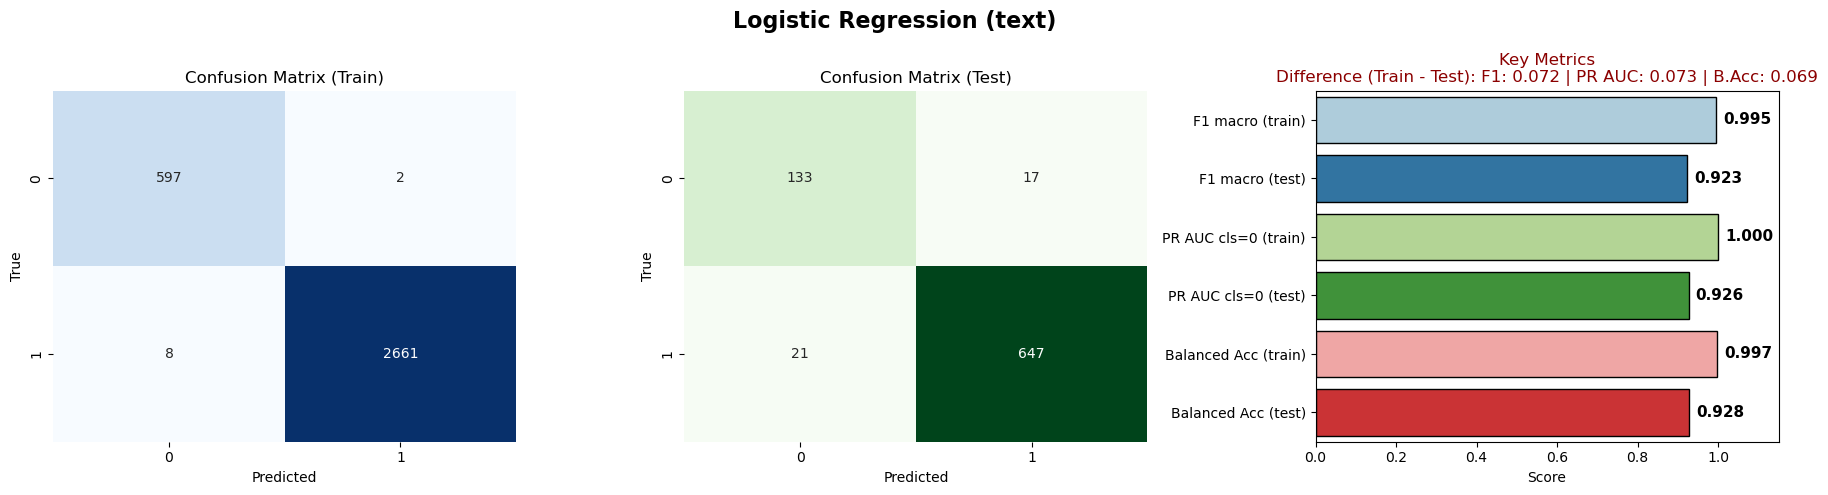

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.864,0.887,0.875,150.000
1,0.974,0.969,0.971,668.000
accuracy,0.954,0.954,0.954,0.954
macro avg,0.919,0.928,0.923,818.000
weighted avg,0.954,0.954,0.954,818.000


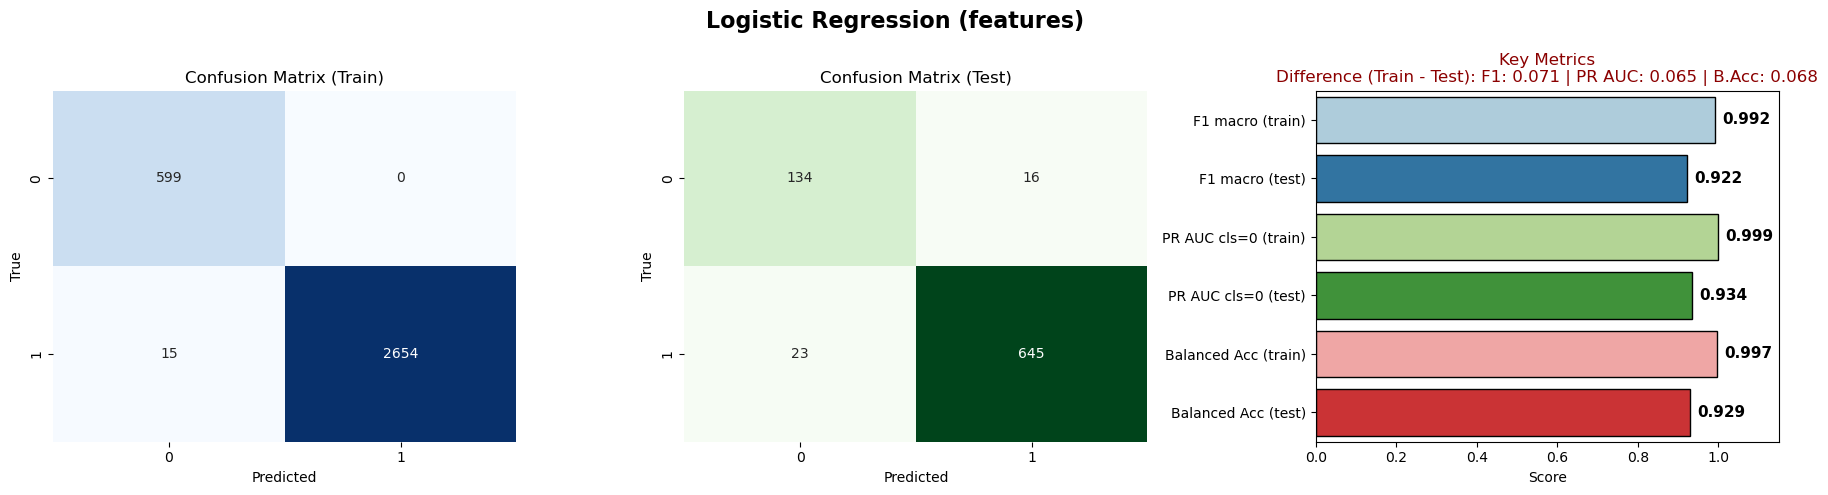

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.854,0.893,0.873,150.000
1,0.976,0.966,0.971,668.000
accuracy,0.952,0.952,0.952,0.952
macro avg,0.915,0.929,0.922,818.000
weighted avg,0.953,0.952,0.953,818.000


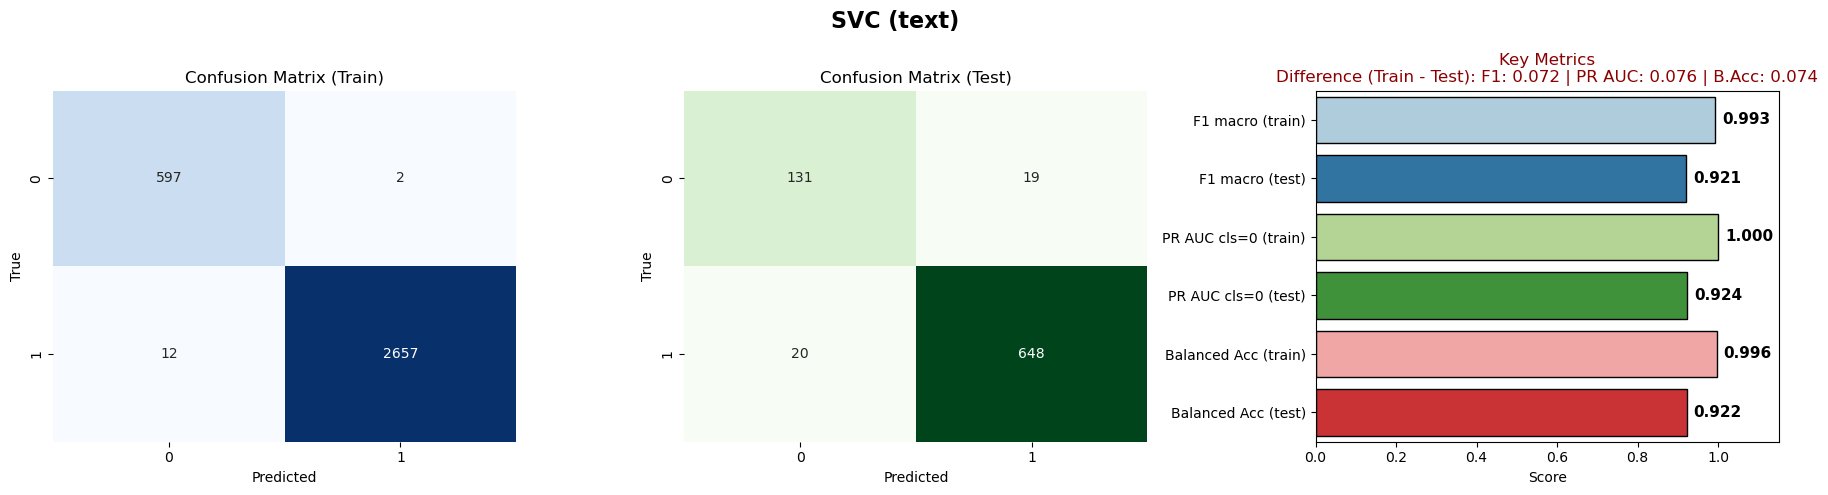

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.868,0.873,0.870,150.000
1,0.972,0.970,0.971,668.000
accuracy,0.952,0.952,0.952,0.952
macro avg,0.920,0.922,0.921,818.000
weighted avg,0.952,0.952,0.952,818.000


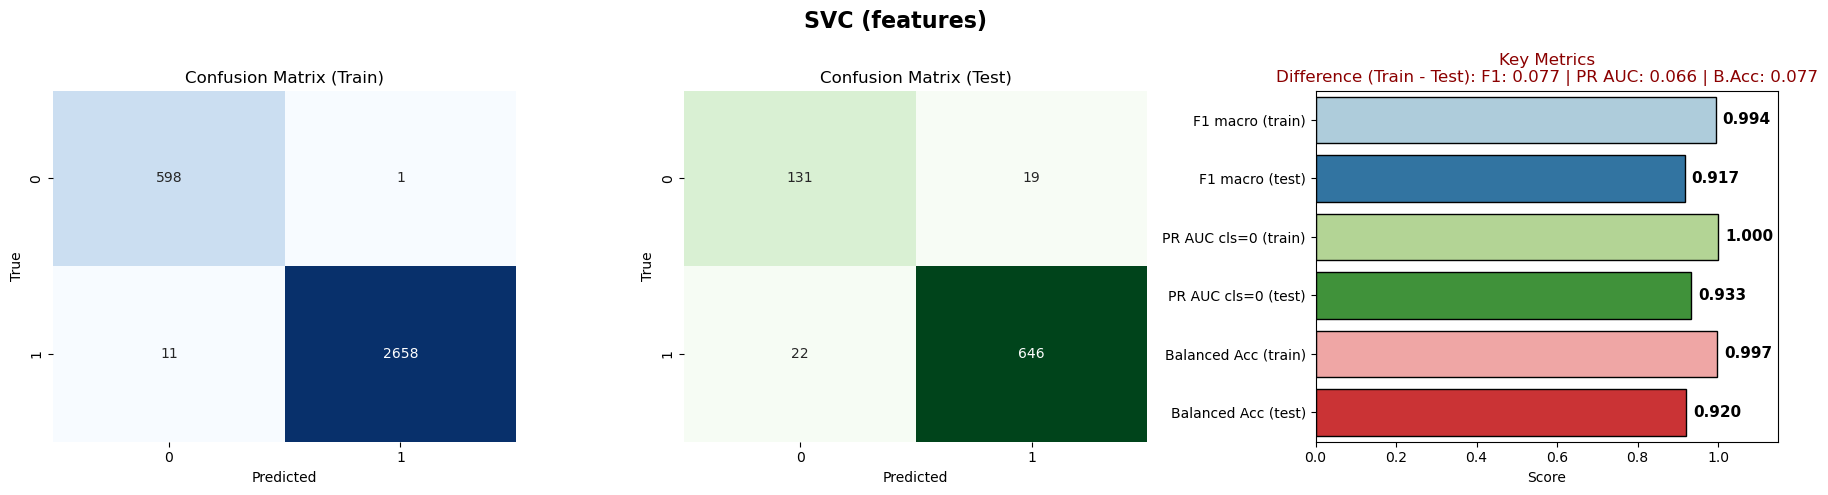

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.856,0.873,0.865,150.00
1,0.971,0.967,0.969,668.00
accuracy,0.950,0.950,0.950,0.95
macro avg,0.914,0.920,0.917,818.00
weighted avg,0.950,0.950,0.950,818.00


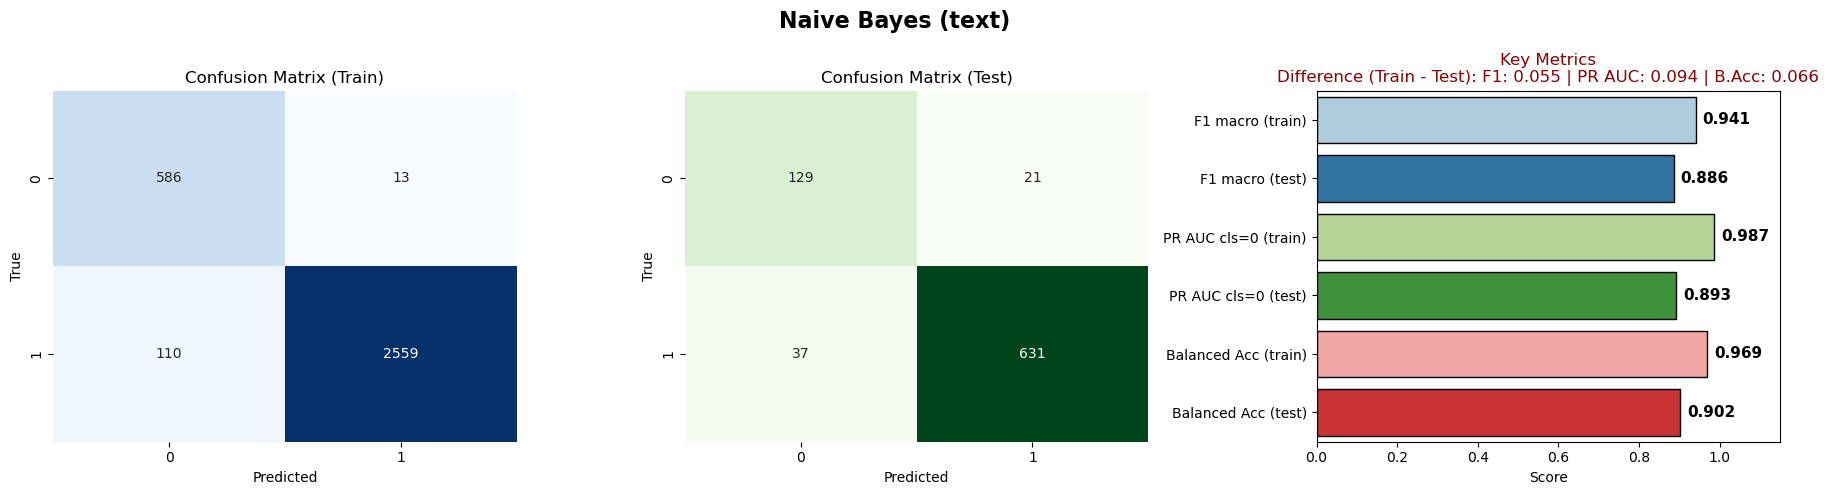

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.777,0.860,0.816,150.000
1,0.968,0.945,0.956,668.000
accuracy,0.929,0.929,0.929,0.929
macro avg,0.872,0.902,0.886,818.000
weighted avg,0.933,0.929,0.930,818.000


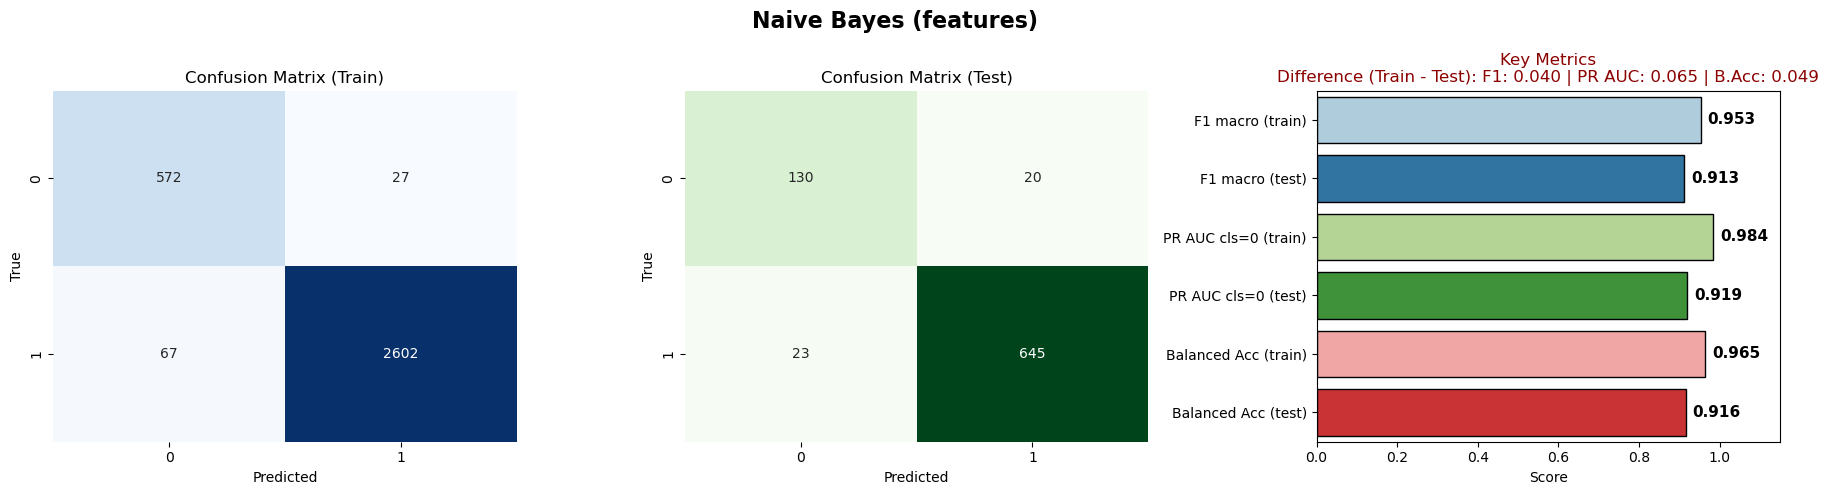

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.850,0.867,0.858,150.000
1,0.970,0.966,0.968,668.000
accuracy,0.947,0.947,0.947,0.947
macro avg,0.910,0.916,0.913,818.000
weighted avg,0.948,0.947,0.948,818.000


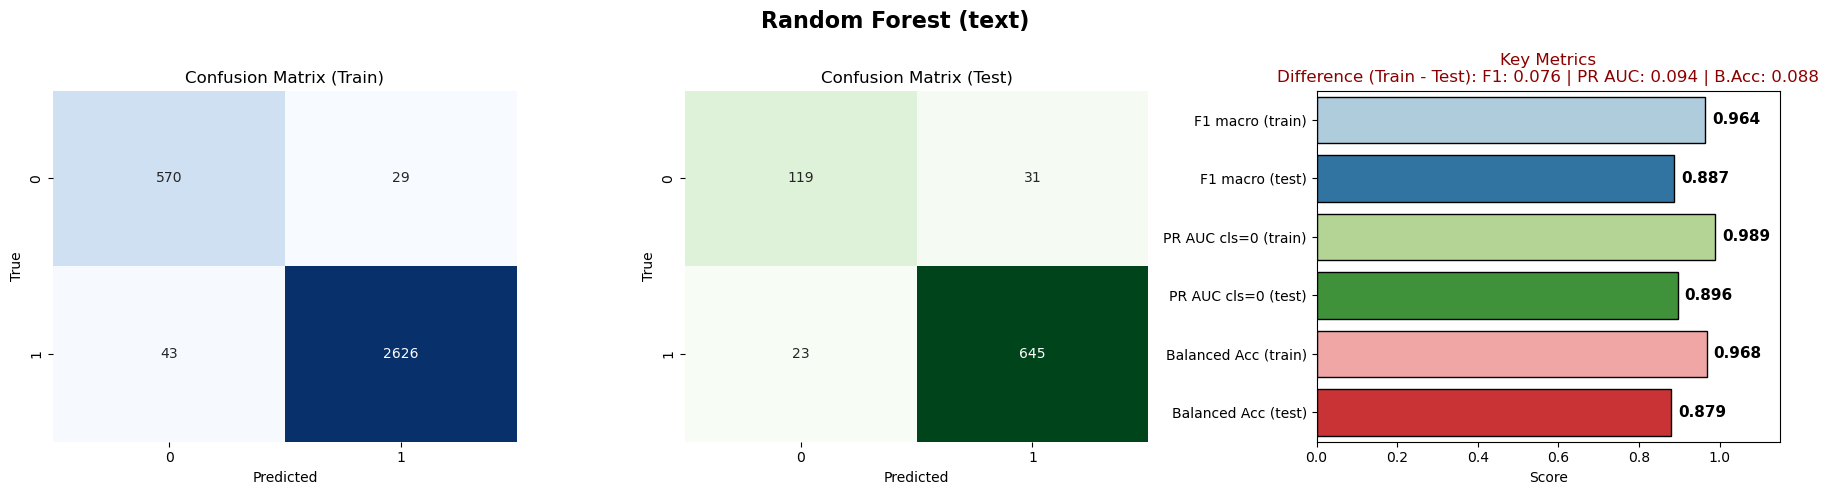

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.838,0.793,0.815,150.000
1,0.954,0.966,0.960,668.000
accuracy,0.934,0.934,0.934,0.934
macro avg,0.896,0.879,0.887,818.000
weighted avg,0.933,0.934,0.933,818.000


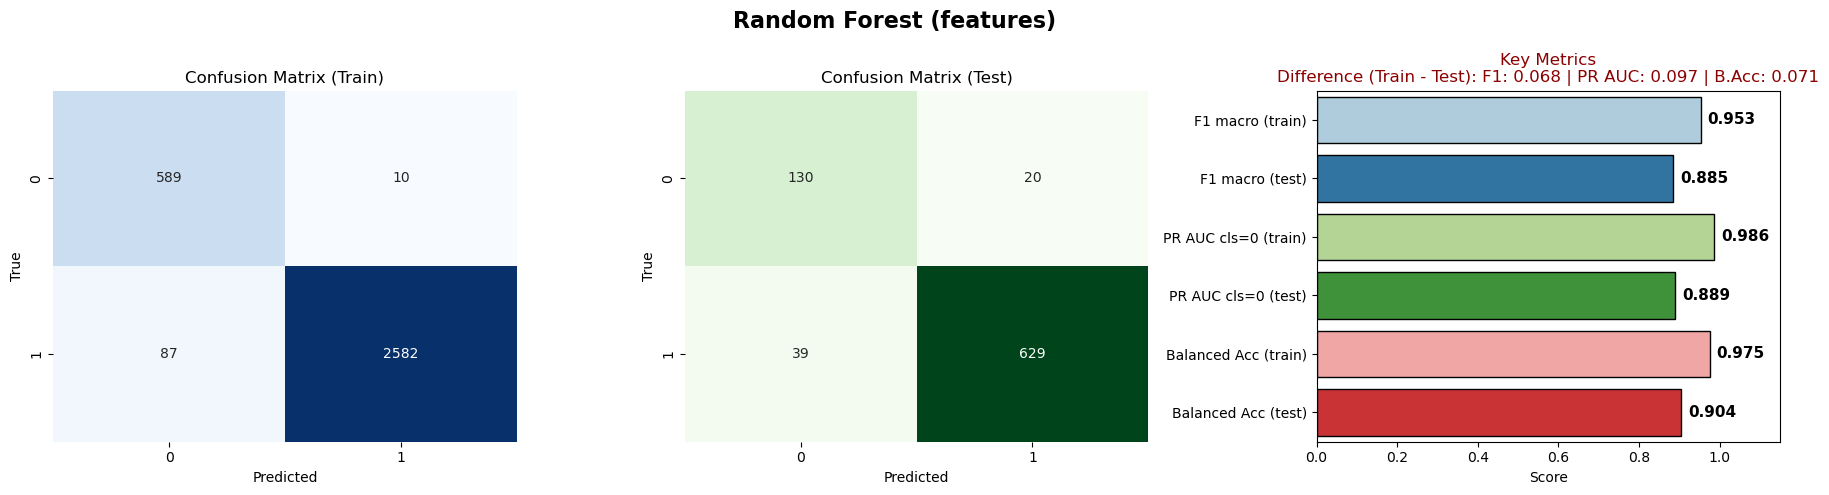

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.769,0.867,0.815,150.000
1,0.969,0.942,0.955,668.000
accuracy,0.928,0.928,0.928,0.928
macro avg,0.869,0.904,0.885,818.000
weighted avg,0.933,0.928,0.930,818.000


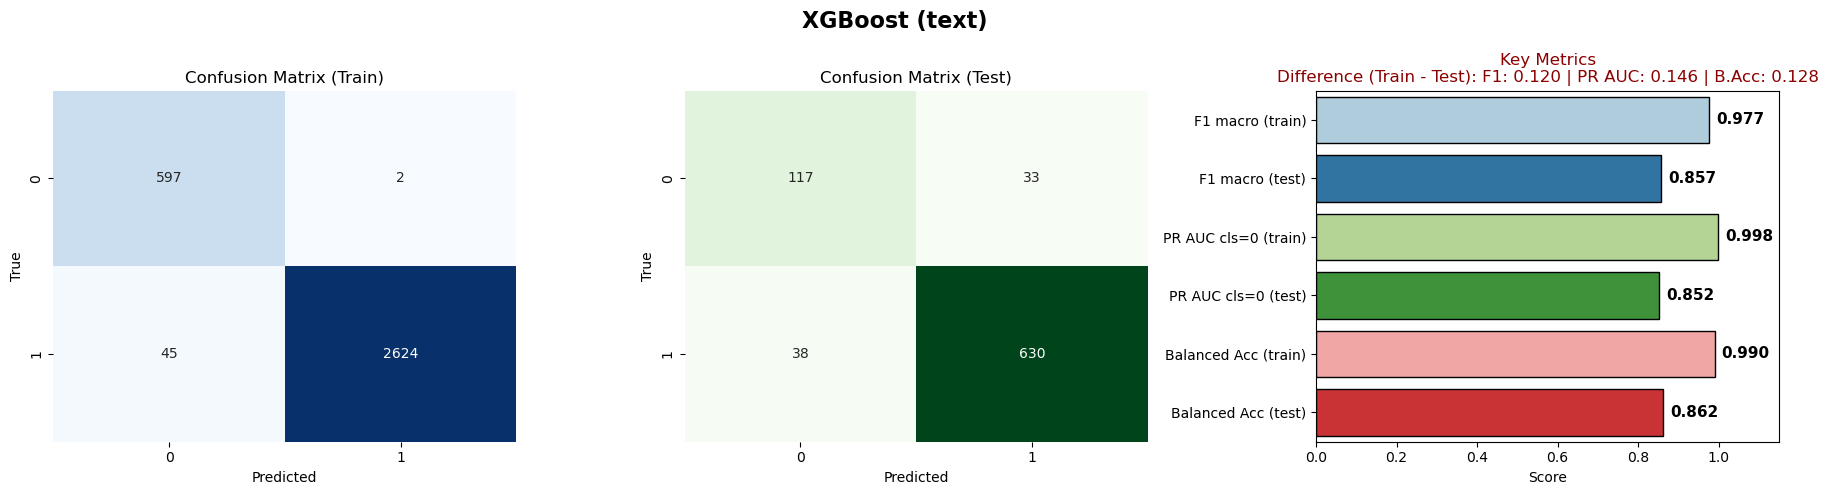

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.755,0.780,0.767,150.000
1,0.950,0.943,0.947,668.000
accuracy,0.913,0.913,0.913,0.913
macro avg,0.853,0.862,0.857,818.000
weighted avg,0.914,0.913,0.914,818.000


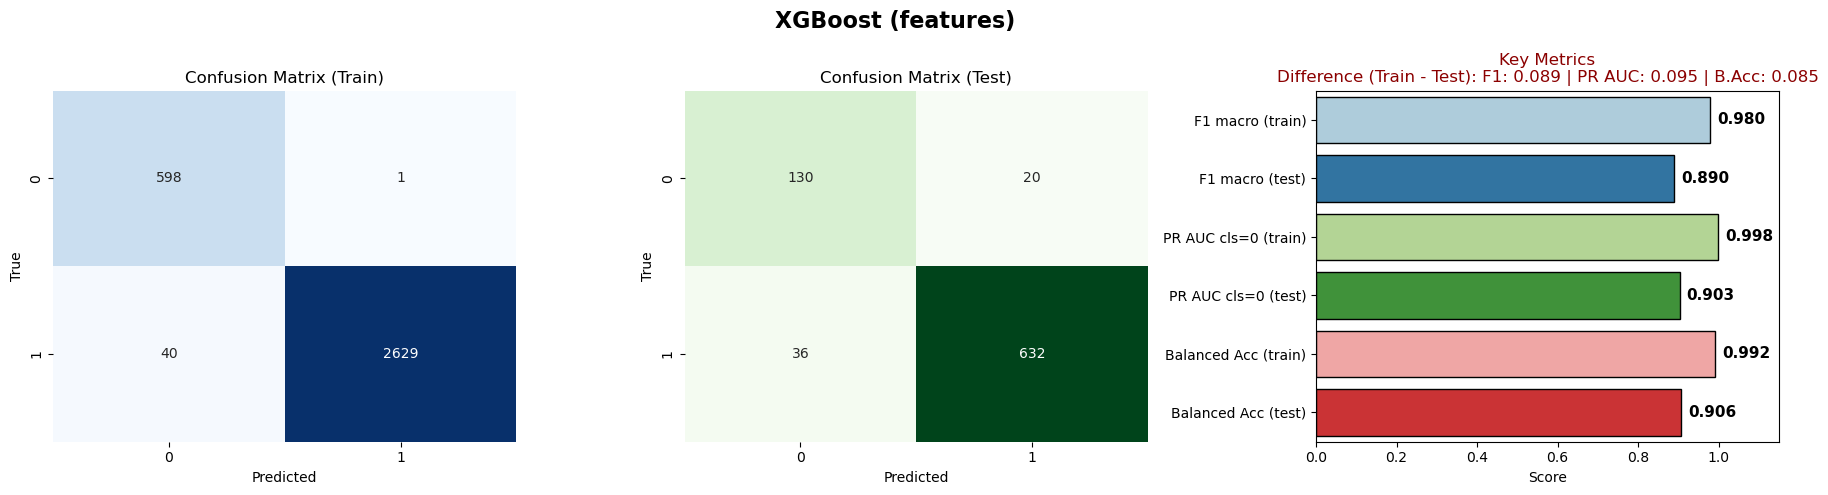

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.783,0.867,0.823,150.000
1,0.969,0.946,0.958,668.000
accuracy,0.932,0.932,0.932,0.932
macro avg,0.876,0.906,0.890,818.000
weighted avg,0.935,0.932,0.933,818.000


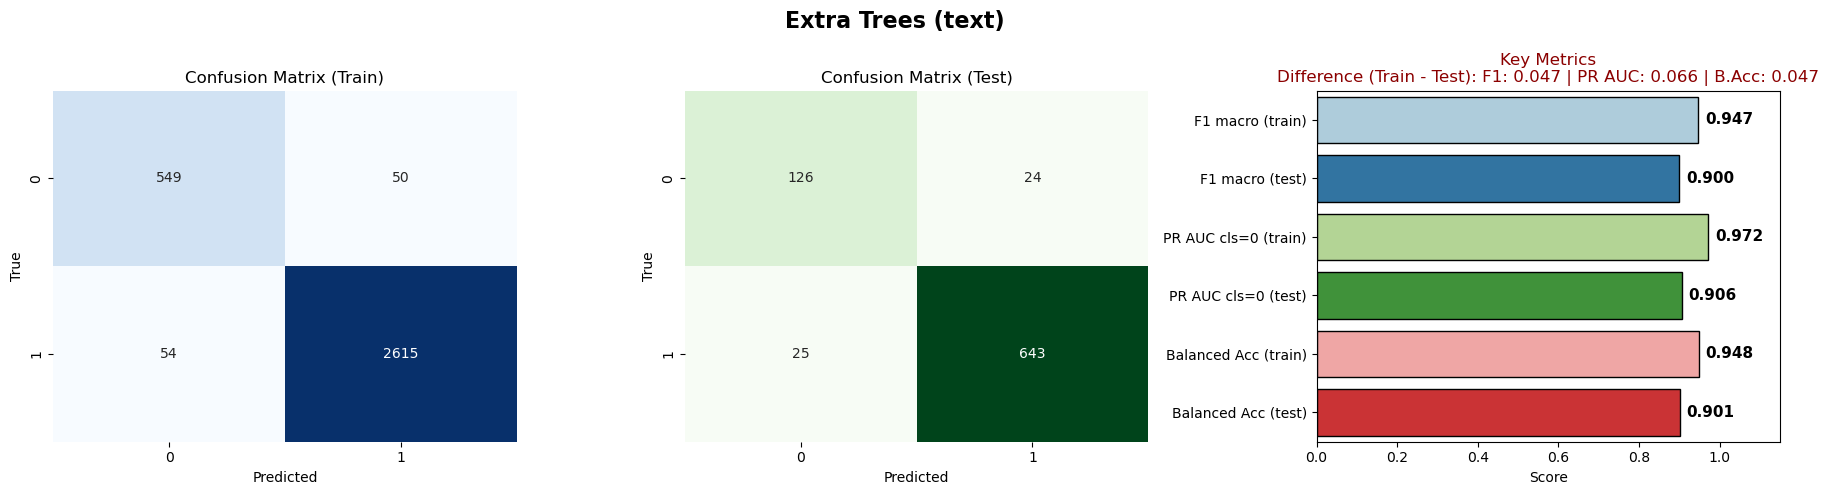

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.834,0.840,0.837,150.00
1,0.964,0.963,0.963,668.00
accuracy,0.940,0.940,0.940,0.94
macro avg,0.899,0.901,0.900,818.00
weighted avg,0.940,0.940,0.940,818.00


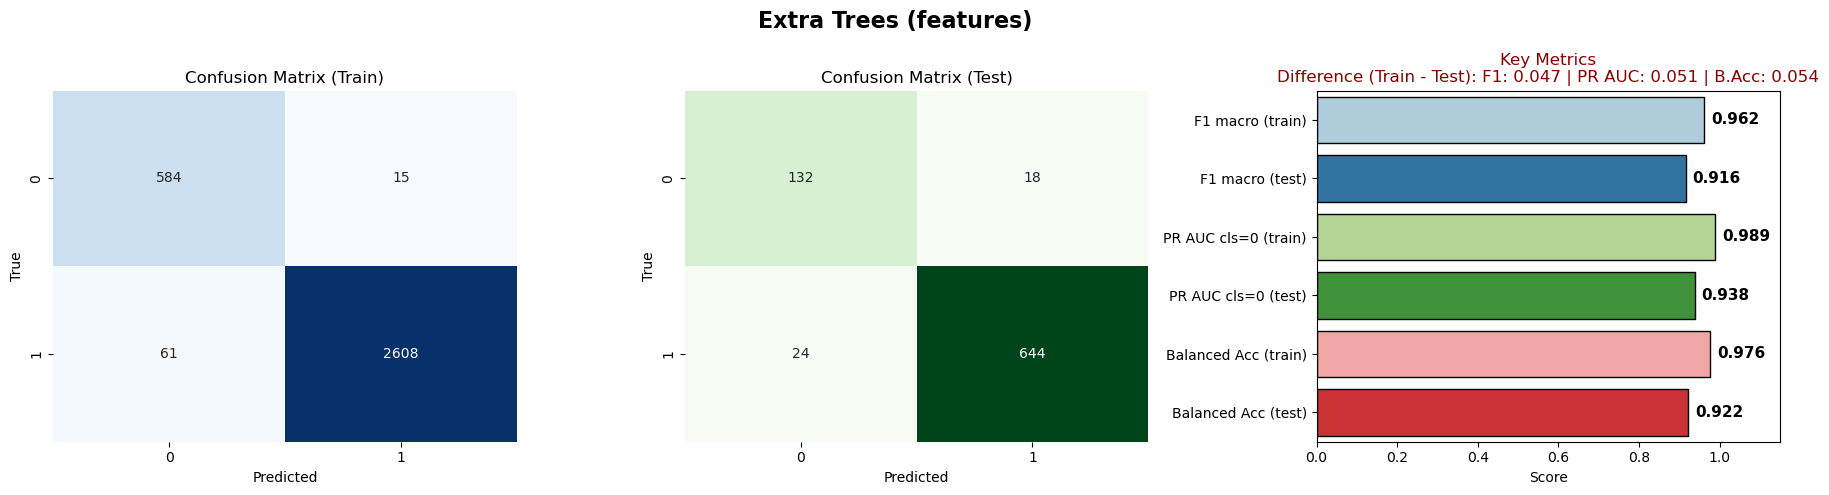

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.846,0.880,0.863,150.000
1,0.973,0.964,0.968,668.000
accuracy,0.949,0.949,0.949,0.949
macro avg,0.909,0.922,0.916,818.000
weighted avg,0.950,0.949,0.949,818.000


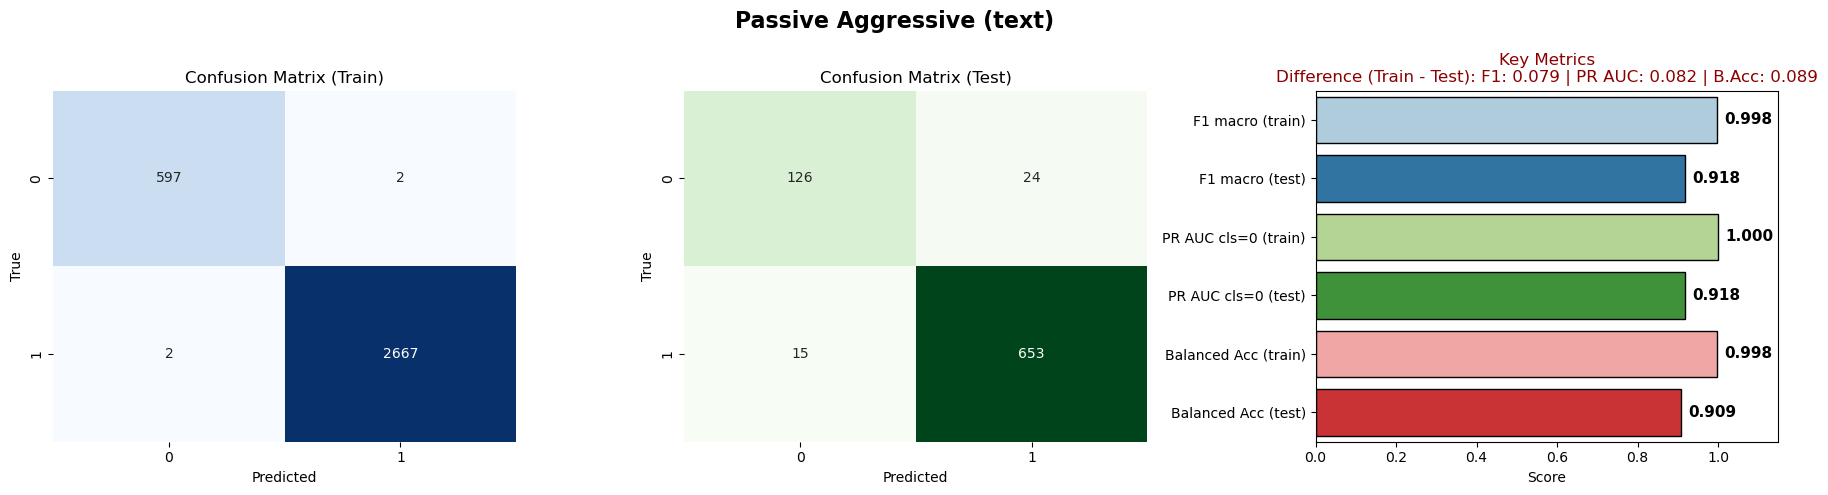

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.894,0.840,0.866,150.000
1,0.965,0.978,0.971,668.000
accuracy,0.952,0.952,0.952,0.952
macro avg,0.929,0.909,0.918,818.000
weighted avg,0.952,0.952,0.952,818.000


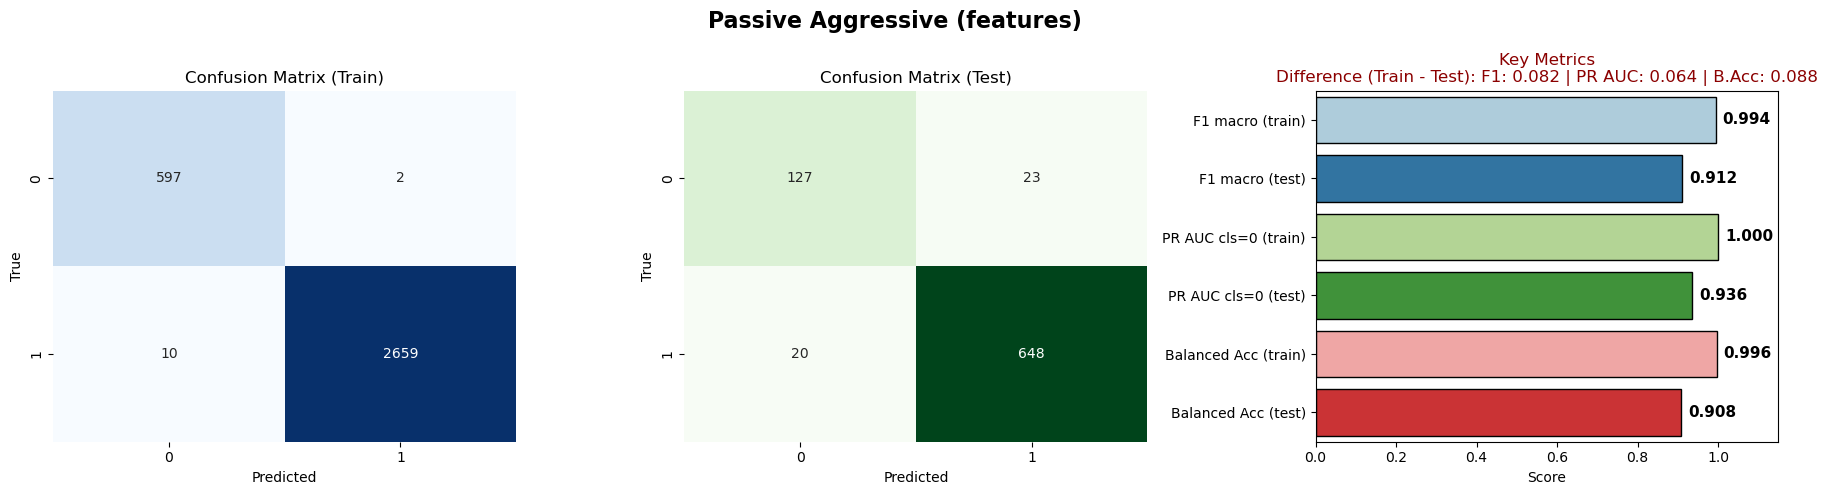

Classification Report (TEST data):


,precision,recall,f1-score,support
0,0.864,0.847,0.855,150.000
1,0.966,0.970,0.968,668.000
accuracy,0.947,0.947,0.947,0.947
macro avg,0.915,0.908,0.912,818.000
weighted avg,0.947,0.947,0.947,818.000


In [7]:
# Dictionary to store trained models
trained_models = {}

for config in models_config:
    model_name = config['name']
    
    # TEXT ONLY

    grid_search_text = GridSearchCV(
        estimator=config['estimator'], 
        param_grid=config['param_grid'], 
        scoring='f1_macro', 
        cv=5, 
        n_jobs=-1
    )
    
    # Train the model 
    grid_search_text.fit(X_train_text, y_train.values.ravel())
    
    # Save the best model to the dictionary 
    trained_models[f"{model_name}_Text"] = grid_search_text.best_estimator_
    
    # Dashboard
    display_model_dashboard(
        f'{model_name} (text)', 
        grid_search_text.best_estimator_, 
        X_train_text, y_train, 
        X_test_text, y_test
    )

    
    # TEXT + FEATURES

    grid_search_features = GridSearchCV(
        estimator=config['estimator'], 
        param_grid=config['param_grid'], 
        scoring='f1_macro', 
        cv=5, 
        n_jobs=-1
    )
    
    grid_search_features.fit(X_train_features, y_train.values.ravel())
    
    trained_models[f"{model_name}_Features"] = grid_search_features.best_estimator_
    
    display_model_dashboard(
        f'{model_name} (features)', 
        grid_search_features.best_estimator_, 
        X_train_features, y_train, 
        X_test_features, y_test
    )
        
    print("\n" + "="*150 + "\n")

#### Generalization Capability and Overfitting Analysis

* **Context**: The dataset exhibits a severe class imbalance (negative reviews: $n=150$, positive reviews: $n=668$). Despite the skewed distribution, the algorithms maintain high predictive power.
* **Stability** (Generalization Gap): Linear models (`Logistic Regression`, `SVC`) and `Extra Trees` demonstrate high generalization capabilities, successfully extracting underlying patterns without merely memorizing the training data.
* **Proneness to Overfitting** (`XGBoost`): Substantial overfitting was observed (a delta of $11–13%$), followed by a degradation in test set performance.

#### Text vs. Text + Features

* The integration of engineered features (text length, punctuation volume, sentiment score) significantly improves the detection quality of the minority (zero) class compared to using text alone.
* Improvement in the target metric, `PR AUC (Class 0)`:
    * `Logistic Regression`: $0.926$ -> $0.934$
    * `Extra Trees`: $0.906$ -> $0.938$
    *` Naive Bayes`: $0.893$ -> $0.919$


* **Conclusion**: Additional predictors provide context that compensates for information lost during standard tokenization.

#### Comparative Model Performance Analysis

* **Text Only**: The leading model is `Logistic Regression` (`F1`: $0.923$, `Balanced Acc`: $0.928$, `PR AUC`: $0.926$).
* **Text + Features**:
    * *Optimal Balance*: `Logistic Regression` delivers the best combination of metrics (`F1`: $0.922$, `Balanced Acc`: $0.929$, `PR AUC`: $0.934$) and yields only $16$ misclassifications on the negative class.
    * *Maximum Recall*: `Extra Trees` shows the best results in detecting the negative class (`PR AUC`: $0.938$) while maintaining a low overfitting rate ($~5%$).

#### Final Model Recommendation

* **Selected Model**: `Logistic Regression` (Text + Features).
* **Justification**:
    * *Effectiveness*: The model outperforms and outpaces the others in the primary task, consistently delivering high-quality results without overfitting.
    * *Computational Complexity*: Low resource requirements (high inference throughput, minimal memory footprint).
    * *Interpretability*: The architecture allows for a direct audit of predictor weights. The decision-making logic is explicitly explainable (e.g., via the analysis of specific token coefficients like `"disgusting"`, and punctuation counters).

## Pipeline Sanity Check on Unseen Data

In [8]:
logreg_text = trained_models['Logistic Regression_Text']

# Assemble a pipeline with only the text vectorizer
logreg_text_pipeline = Pipeline(steps=[
    ('preprocessor', text_pipeline),
    ('classifier', logreg_text)
])

# New raw reviews for testing
new_raw_reviews = [
    "The food was absolutely disgusting, I will never go back.",
    "Amazing service and the steak was cooked to perfection! 5 stars!",
    "It was okay, nothing special but not bad either."
]

# Predictions
predictions = logreg_text_pipeline.predict(new_raw_reviews)
print(predictions)

[0 1 0]


In [9]:
# Transform our new reviews into vectors
X_new_vectors = text_pipeline.transform(new_raw_reviews)

feature_names = text_pipeline.named_steps['tfidf'].get_feature_names_out()

# Loop through the new reviews
for idx, text in enumerate(new_raw_reviews):
    # Extract recognized words for the current review (by index)
    words_found = [feature_names[i] for i in X_new_vectors[idx].nonzero()[1]]
    
    print(f"--- Review {idx + 1} ---")
    print(f"Original: {text}")
    print(f"What the model understood: {words_found}\n")

--- Review 1 ---
Original: The food was absolutely disgusting, I will never go back.
What the model understood: ['absolutely', 'disgusting', 'food', 'food absolutely', 'never']

--- Review 2 ---
Original: Amazing service and the steak was cooked to perfection! 5 stars!
What the model understood: ['amazing', 'amazing service', 'cook', 'cook perfection', 'perfection', 'service', 'star', 'steak']

--- Review 3 ---
Original: It was okay, nothing special but not bad either.
What the model understood: ['bad', 'not', 'not bad', 'nothing', 'nothing special', 'okay', 'special']



#### Pipeline Testing on Unseen Data

* **Prediction Adequacy:** The model confidently and correctly recognized polar reviews (explicit negative reviews received label `0`, absolute positive ones received label `1`).
* **Model Limitation:** The third review ("It was okay...") is contextually mixed or neutral (a 2-3 star rating). The fact that the algorithm assigned it to class `0` clearly demonstrates the limitation of the binary classification approach.
* **Transparency:** `TF-IDF` successfully extracted not only individual words (`'disgusting'`, `'amazing'`), but also meaningful bigrams (`'food absolutely'`, `'cook perfection'`). Lemmatization worked effectively: `"cooked"` was converted to `cook`, and `"stars"` to `star`.
* **Preservation of Negation Context:** The third review shows that the custom text cleaning function worked as intended. Negation particles were not removed as stop words (`'not bad'` and `'nothing special'`).

## Error Analysis

In [10]:
logreg_model = trained_models['Logistic Regression_Features']

full_logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', logreg_model) 
])

# Get predictions and probabilities
y_pred = full_logreg_pipeline.predict(X_test)
y_proba = full_logreg_pipeline.predict_proba(X_test)

# Combine everything into a single DataFrame
errors_df = pd.DataFrame({
    'text': X_test['text'],  # Original text
    'true_label': y_test.values if isinstance(y_test, pd.Series) else y_test,
    'predicted': y_pred,
    'prob_0': y_proba[:, 0], # Negative class probability
    'prob_1': y_proba[:, 1]  # Positive class probability
})

# Keep ONLY the errors
errors_df = errors_df[errors_df['true_label'] != errors_df['predicted']]

# Split into two types of errors 

# False Positives
fp_errors = errors_df[(errors_df['true_label'] == 0) & (errors_df['predicted'] == 1)]
fp_errors = fp_errors.sort_values(by='prob_1', ascending=False)

# False Negatives
fn_errors = errors_df[(errors_df['true_label'] == 1) & (errors_df['predicted'] == 0)]
fn_errors = fn_errors.sort_values(by='prob_0', ascending=False)

print("TOP 5 ERRORS: False Positives")

for i, row in fp_errors.head(5).iterrows():
    print(f"Confidence in positive: {row['prob_1']*100:.1f}%")
    print(f"Text: {row['text']}\n")
    print("-" * 50)

TOP 5 ERRORS: False Positives
Confidence in positive: 99.8%
Text: Remember how I said that the Trivia was the best thing about this place?  Well, they got rid of long time Triva host, Dave (who had been featured in the College Times and was the best thing about the trivia).  Without Dave's personality, this place just doesn't cut it.  Will never go here again. Bummer.

--------------------------------------------------
Confidence in positive: 96.8%
Text: Tried a couple Tammie Coe cupcakes and a mini muffin two weeks ago... Unfortunately for them, I also sampled Ollie Cakes... No wonder Ollie Cakes, aka Urban Cookie, won Cupcake Wars and Tammie Coe sits in high rent selling pretty sugar disguised as a cupcake.

Drive a few miles north, get whatever the special cupcake of the day is along with a Brown Velvet and Lemon, and save saying you enjoyed Tammie Coe for impressing snooty folk who wouldn't know yummy if it bit them on the butt!

Really, the TC cakes were just cakes... No flavor, n

#### Error Analysis on False Positives

An analysis of the model's top 5 most confident errors (where the algorithm predicted a positive outcome with a >93% probability for actual negative reviews) revealed fundamental limitations of the `TF-IDF`-based approach:

* **Inability to recognize sarcasm:** The algorithm interprets words like *"happy"*, *"impressed"*, or *"Wow"* literally, missing the ironic context (e.g., *"staff will be happy to serve you with bare hands"*).
* **Comparison with competitors:** If the reviewer praises another establishment (e.g., *"go to Z Pizza... for great pizza instead"*), the model mistakenly attributes these positive tokens (`"great"`, `"yummy"`) to the current restaurant.
* **Blindness to temporal context:** The model highly weights markers like *"best thing"*, failing to understand that the author is referring to a lost advantage in the past tense (*"Trivia was the best thing... they got rid of [it]"*).
* **Mixed sentiment (Food vs. Service):** In lengthy reviews, strong praise for one aspect (food) can mathematically "outweigh" the criticism of another aspect (service), causing the linear model to ignore the user's overall negative verdict.

**Conclusion:** The current architecture excels at handling explicitly expressed sentiment but falls short when dealing with complex linguistic constructs. To resolve such edge cases in the future, a transition from `Bag-of-Words` to contextual language models capable of capturing these nuances will be required.

## Feature Importance via Model Coefficients

In [11]:
# Get text feature names from the ColumnTransformer (TF-IDF words)
text_feature_names = full_logreg_pipeline.named_steps['preprocessor'].named_transformers_['text'].named_steps['tfidf'].get_feature_names_out()

# Numerical features (engineered features: num_exclam, lengths, etc.)
num_feature_names = full_logreg_pipeline.named_steps['preprocessor'].named_transformers_['num'].get_feature_names_out()

# Combine all feature names into a single list
all_feature_names = list(text_feature_names) + list(num_feature_names)

# Extract the coefficients (weights)
coefficients = logreg_model.coef_[0]

# Create a DataFrame with feature names and their corresponding weights  
weights_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Weight': coefficients
})

# Top 20 negative markers (pulling towards Class 0)
top_class_0 = weights_df.sort_values(by='Weight', ascending=True).head(20)

# Top 20 positive markers (pulling towards Class 1)
top_class_1 = weights_df.sort_values(by='Weight', ascending=False).head(20)

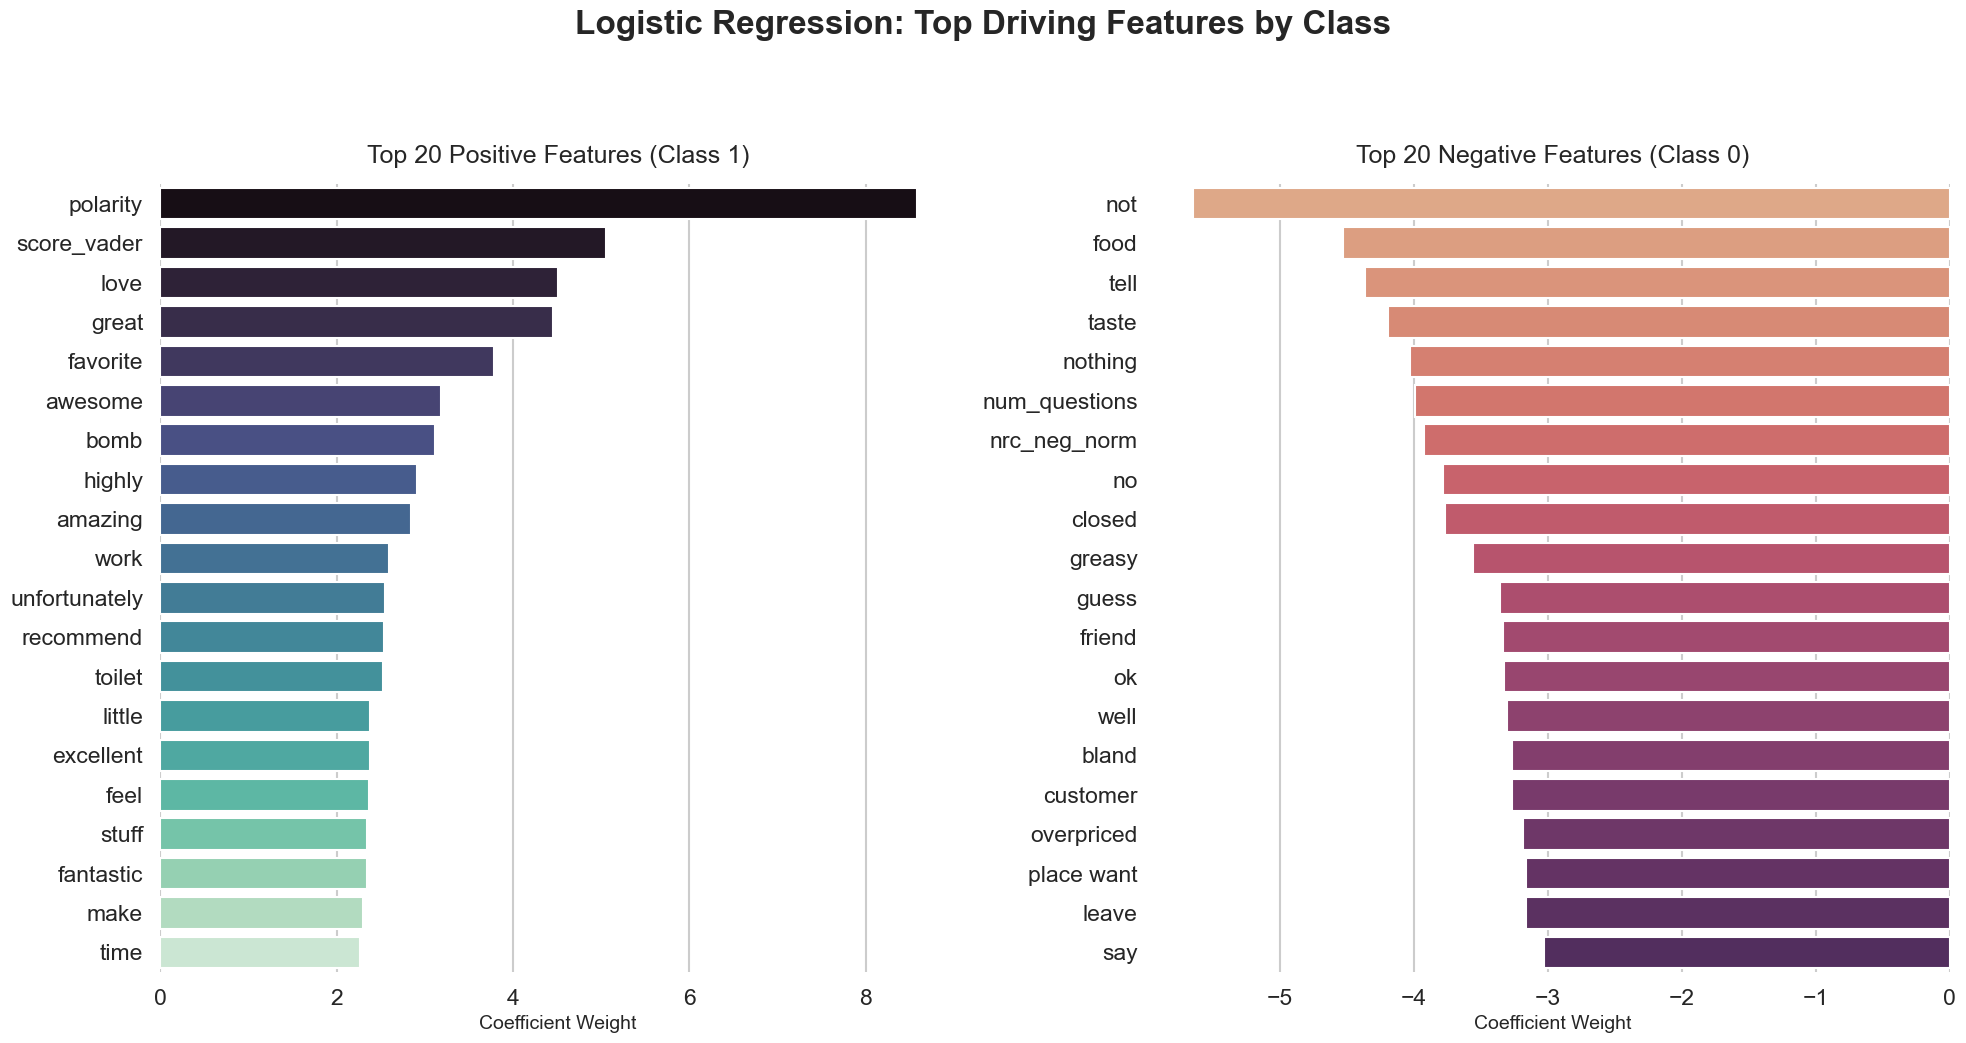

In [12]:
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Logistic Regression: Top Driving Features by Class", fontsize=24, fontweight='bold', y=1.05)

# Plot for Class 1 (Positive)
sns.barplot(
    data=top_class_1, 
    x='Weight', 
    y='Feature', 
    palette='mako', 
    ax=axes[0]
)
axes[0].set_title("Top 20 Positive Features (Class 1)", fontsize=18, pad=15)
axes[0].set_xlabel("Coefficient Weight", fontsize=14)
axes[0].set_ylabel("") # Remove the 'Feature' label 

# Plot for Class 0 (Negative)
sns.barplot(
    data=top_class_0, 
    x='Weight', 
    y='Feature', 
    palette='flare', 
    ax=axes[1]
)
axes[1].set_title("Top 20 Negative Features (Class 0)", fontsize=18, pad=15)
axes[1].set_xlabel("Coefficient Weight", fontsize=14)
axes[1].set_ylabel("") 

# Clean up borders and layout
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

#### Analysis of Logistic Regression Coefficients

- **Domination of Meta-features:** The engineered features (`polarity`, `score_vader`) hold the highest predictive power for the positive class. For the negative class, `nrc_neg_norm` and `num_questions` proved to be highly significant.
- **Preprocessing Effectiveness:** The strongest negative marker is the token `not`. This proves the importance of the custom text cleaning function, which preserved negation particles from being removed along with other stop words.
- **Domain Specificity:** The model correctly learned specific product-related negative markers (`greasy`, `bland`, `overpriced`), as well as slang expressions of approval (the token `bomb`).
- **Interesting Anomalies (Food for thought):** There are a couple of strange artifacts on the left chart (positive class):
    - `unfortunately` — surprisingly pulls towards the positive class. Most likely, reviewers are writing things like: *"Unfortunately, I live too far away to come here every day"* or *"Unfortunately, I can only give it 5 stars."*
    - `toilet` — also ended up in the positive class. Perhaps clean restrooms at the establishment delight the guests, and they frequently highlight it: *"Even the toilet was sparkling clean!"*